# EDA: GREYC-NISLAB Keystroke Benchmark Dataset
## Typing Pattern User Identification

This notebook performs exploratory data analysis on the GREYC-NISLAB keystroke dynamics dataset to justify building a user identification system based on typing patterns.

---

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

file_path = "GREYC-NISLABKeystrokeBenchmarkDatasetSyed.xlsx"

xls = pd.ExcelFile(file_path)

print("Sheets:")
print(xls.sheet_names)

Sheets:
['P1', 'P2', 'P3', 'P4', 'P5']


## 2. Load Dataset

In [3]:
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)

    print("=" * 60)
    print(f"Sheet: {sheet}")
    print(f"Shape: {df.shape}")
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    display(df.head())

Sheet: P1
Shape: (2200, 7)

Columns:
['User_ID', 'Gender', 'Age', 'Handedness', 'Password', 'Class', 'Keystroke Template Vector']

First 5 rows:


,User_ID,Gender,Age,Handedness,Password,Class,Keystroke Template Vector
0,1,F,34,L,leonardo dicaprio,1,10230000 4720000 5760000 3520000 2150000 1840000 4560000 4000000 2880000 4480000 4160000 2240000 3600000 3760000 3360000 1790000 10540000 4410000 5790000 3490000 2160000 1840000 4580000 3980000 31...
1,1,F,34,L,leonardo dicaprio,1,4400000 2710000 4720000 3150000 2130000 1600000 3120000 2560000 3840000 2640000 4010000 2150000 3760000 4330000 3030000 1680000 4070000 2810000 4480000 3360000 2080000 1680000 3120000 2650000 375...
2,1,F,34,L,leonardo dicaprio,1,3760000 2400000 3360000 3520000 2400000 1440000 3040000 2640000 3520000 2400000 3280000 3830000 4250000 5910000 2410000 1440000 3380000 2300000 3600000 3560000 2360000 1430000 2810000 2880000 327...
3,1,F,34,L,leonardo dicaprio,1,3520000 2640000 2800000 3360000 2160000 1840000 3120000 2400000 6160000 2560000 3840000 2320000 4080000 3760000 2640000 1440000 3520000 2640000 2800000 3360000 2160000 1840000 3120000 2320000 624...
4,1,F,34,L,leonardo dicaprio,1,3520000 2880000 3520000 3490000 1950000 1440000 2880000 2560000 2670000 2920000 3690000 2640000 3760000 4320000 2560000 1680000 3520000 3120000 3280000 3600000 2080000 1440000 2880000 2650000 255...


Sheet: P2
Shape: (2200, 7)

Columns:
['User_ID', 'Gender', 'Age', 'Handedness', 'Password', 'Class', 'Keystroke Template Vector']

First 5 rows:


,User_ID,Gender,Age,Handedness,Password,Class,Keystroke Template Vector
0,1,F,34,L,the rolling stones,1,2450000 3230000 3600000 5920000 2800000 3860000 1900000 3280000 3840000 4230000 2410000 3270000 2400000 2800000 3360000 3360000 1840000 2400000 3520000 3590000 5680000 3050000 3830000 1680000 3520...
1,1,F,34,L,the rolling stones,1,1840000 2640000 4240000 2880000 2680000 2040000 1440000 2020000 2700000 3120000 2170000 2790000 2400000 2640000 3520000 2640000 2080000 1890000 2590000 4240000 2640000 2880000 2080000 1440000 168...
2,1,F,34,L,the rolling stones,1,1920000 2640000 4720000 2640000 2560000 2650000 1430000 2090000 3110000 2880000 2080000 3360000 2560000 2400000 3120000 3040000 1680000 1920000 2640000 4720000 2640000 2560000 2640000 1440000 208...
3,1,F,34,L,the rolling stones,1,1920000 2320000 2150000 2410000 2320000 2410000 1430000 2300000 3380000 2390000 5200000 7840000 1920000 2320000 2640000 2640000 1840000 1920000 2310000 2160000 2160000 2800000 2160000 1440000 217...
4,1,F,34,L,the rolling stones,1,1440000 2560000 2640000 5920000 2880000 2390000 1610000 2160000 3520000 6180000 2380000 3120000 1840000 2400000 2800000 3120000 1920000 1680000 2320000 2640000 5920000 2880000 2320000 1680000 240...


Sheet: P3
Shape: (2200, 7)

Columns:
['User_ID', 'Gender', 'Age', 'Handedness', 'Password', 'Class', 'Keystroke Template Vector']

First 5 rows:


,User_ID,Gender,Age,Handedness,Password,Class,Keystroke Template Vector
0,1,F,34,L,michael schumacher,1,2400000 4080000 2080000 3120000 2160000 3760000 2640000 3760000 1920000 2080000 1920000 2640000 4000000 3600000 2320000 2160000 1680000 2400000 4080000 2080000 3120000 2080000 3840000 2640000 3760...
1,1,F,34,L,michael schumacher,1,2160000 4720000 2160000 3360000 2080000 3600000 2560000 3360000 1920000 2320000 1920000 2640000 4000000 2640000 2560000 2160000 1690000 1960000 4720000 2160000 3360000 2080000 3600000 2560000 336...
2,1,F,34,L,michael schumacher,1,3040000 4320000 2080000 3360000 2180000 3020000 2750000 5090000 2880000 2320000 1920000 2640000 4000000 2630000 2320000 2180000 1900000 2800000 4560000 1840000 3590000 2160000 3290000 2150000 544...
3,1,F,34,L,michael schumacher,1,2640000 4480000 2160000 3040000 2160000 3360000 2560000 3120000 2160000 2080000 2160000 2400000 4720000 8800000 2080000 2160000 1440000 2550000 4090000 2400000 3040000 2160000 3600000 2320000 312...
4,1,F,34,L,michael schumacher,1,4080000 4000000 2160000 3280000 1950000 3090000 2560000 3360000 1920000 2320000 1920000 2640000 4720000 2800000 2400000 2160000 1680000 3860000 4220000 2160000 3210000 1990000 3120000 2320000 336...


Sheet: P4
Shape: (2200, 7)

Columns:
['User_ID', 'Gender', 'Age', 'Handedness', 'Password', 'Class', 'Keystroke Template Vector']

First 5 rows:


,User_ID,Gender,Age,Handedness,Password,Class,Keystroke Template Vector
0,1,F,34,L,red hot chilli peppers,1,7360000 2320000 3360000 2560000 2640000 3360000 2800000 2160000 2160000 2160000 2560000 1440000 2080000 2640000 11170000 5470000 3280000 1500000 4180000 1680000 2160000 7350000 2400000 3040000 256...
1,1,F,34,L,red hot chilli peppers,1,2400000 1680000 2320000 2670000 2370000 2800000 2640000 2290000 2190000 1920000 2640000 1360000 1920000 2640000 2560000 3600000 3280000 1440000 4080000 1360000 2160000 2160000 1920000 2080000 264...
2,1,F,34,L,red hot chilli peppers,1,1600000 2160000 3600000 3330000 2350000 3040000 2880000 2160000 2080000 1680000 2880000 1360000 1920000 2160000 2800000 3840000 4000000 1440000 4090000 1350000 1920000 1770000 1920000 3660000 322...
3,1,F,34,L,red hot chilli peppers,1,1680000 1920000 2080000 2160000 2710000 2730000 2640000 2190000 2050000 2160000 3760000 1430000 6880000 6890000 2630000 3760000 3600000 1200000 3780000 1660000 1680000 1680000 1920000 2080000 244...
4,1,F,34,L,red hot chilli peppers,1,1680000 1680000 5920000 1920000 2400000 2320000 2400000 1600000 2160000 1950000 2290000 1280000 1600000 3520000 2640000 3840000 3040000 1440000 3280000 1680000 1920000 1680000 1740000 5860000 192...


Sheet: P5
Shape: (2200, 7)

Columns:
['User_ID', 'Gender', 'Age', 'Handedness', 'Password', 'Class', 'Keystroke Template Vector']

First 5 rows:


,User_ID,Gender,Age,Handedness,Password,Class,Keystroke Template Vector
0,1,F,34,L,united states of america,1,2080000 2650000 3990000 2640000 1690000 2310000 2640000 2160000 3040000 2400000 2160000 1840000 2400000 3040000 4560000 1920000 2560000 3860000 3740000 1720000 2520000 4320000 2460000 2330000 2630...
1,1,F,34,L,united states of america,1,2300000 2640000 2800000 2160000 1920000 2560000 2400000 1920000 2570000 2390000 1920000 1840000 2230000 2810000 3520000 1920000 2560000 3600000 3520000 1680000 2400000 3760000 2400000 2160000 240...
2,1,F,34,L,united states of america,1,1920000 1840000 3120000 2400000 2080000 2460000 2980000 2640000 2880000 2320000 2160000 1680000 2320000 2640000 3360000 1840000 2640000 3280000 3600000 1920000 2320000 4080000 2320000 2170000 183...
3,1,F,34,L,united states of america,1,2080000 1920000 2560000 3640000 2040000 2400000 2160000 2080000 2630000 2650000 2070000 2410000 2390000 2800000 3360000 2080000 2640000 3600000 4240000 1680000 2800000 4080000 2560000 1920000 216...
4,1,F,34,L,united states of america,1,1920000 2400000 4480000 2220000 1780000 2400000 2400000 1840000 2640000 2400000 2320000 1920000 2420000 3020000 4560000 2360000 2600000 3520000 3600000 1440000 2560000 3600000 2320000 1920000 240...


## 3. Parse Keystroke Template Vectors

In [4]:
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)

    lengths = df["Keystroke Template Vector"].astype(str).apply(
        lambda x: len(x.strip().split())
    )

    print("=" * 60)
    print(f"Sheet: {sheet}")
    print("Unique vector lengths:", sorted(lengths.unique()))
    print("Min length:", lengths.min())
    print("Max length:", lengths.max())
    print("Mean length:", lengths.mean())

Sheet: P1
Unique vector lengths: [np.int64(64)]
Min length: 64
Max length: 64
Mean length: 64.0
Sheet: P2
Unique vector lengths: [np.int64(68)]
Min length: 68
Max length: 68
Mean length: 68.0
Sheet: P3
Unique vector lengths: [np.int64(68)]
Min length: 68
Max length: 68
Mean length: 68.0
Sheet: P4
Unique vector lengths: [np.int64(84)]
Min length: 84
Max length: 84
Mean length: 84.0
Sheet: P5
Unique vector lengths: [np.int64(92)]
Min length: 92
Max length: 92
Mean length: 92.0


## 4. Feature Vector Length Analysis

In [5]:
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)

    print("="*60)
    print(sheet)

    print("Unique Users:", df["User_ID"].nunique())

    print("\nSamples per User:")
    print(df["User_ID"].value_counts().describe())

P1
Unique Users: 110

Samples per User:
count    110.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
Name: count, dtype: float64
P2
Unique Users: 110

Samples per User:
count    110.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
Name: count, dtype: float64
P3
Unique Users: 110

Samples per User:
count    110.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
Name: count, dtype: float64
P4
Unique Users: 110

Samples per User:
count    110.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
Name: count, dtype: float64
P5
Unique Users: 110

Samples per User:
count    110.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
Name: count, dtype: float64


Different passwords produce different feature vector lengths (64, 68, 84, 92). This is expected as the vectors are password-dependent.

## 5. Pad All Vectors to Max Length

In [6]:
# Load P1
df_p1 = pd.read_excel(file_path, sheet_name="P1")

# Convert vector string to list
vectors = df_p1["Keystroke Template Vector"].astype(str).apply(
    lambda x: [int(v) for v in x.split()]
)

# Create feature dataframe
feature_df = pd.DataFrame(
    vectors.tolist(),
    columns=[f"F{i+1}" for i in range(64)]
)

# Combine metadata + features
p1_data = pd.concat(
    [
        df_p1[["User_ID", "Gender", "Age", "Handedness", "Class"]],
        feature_df
    ],
    axis=1
)

print("Shape:", p1_data.shape)
display(p1_data.head())

Shape: (2200, 69)


,User_ID,Gender,Age,Handedness,Class,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30,F31,F32,F33,F34,F35,F36,F37,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47,F48,F49,F50,F51,F52,F53,F54,F55,F56,F57,F58,F59,F60,F61,F62,F63,F64
0,1,F,34,L,1,10230000,4720000,5760000,3520000,2150000,1840000,4560000,4000000,2880000,4480000,4160000,2240000,3600000,3760000,3360000,1790000,10540000,4410000,5790000,3490000,2160000,1840000,4580000,3980000,3120000,4240000,4080000,2080000,3840000,3520000,3600000,1680000,9520000,3700000,5050000,2780000,1440000,1120000,3840000,3260000,2160000,3520000,3440000,1600000,3120000,3040000,2880000,1070000,11250000,5430000,6500000,4230000,2870000,2560000,5300000,4720000,3840000,5200000,4800000,2720000,4320000,4240000,4080000,2400000
1,1,F,34,L,1,4400000,2710000,4720000,3150000,2130000,1600000,3120000,2560000,3840000,2640000,4010000,2150000,3760000,4330000,3030000,1680000,4070000,2810000,4480000,3360000,2080000,1680000,3120000,2650000,3750000,2640000,3760000,2160000,4240000,4080000,3040000,1920000,3450000,2090000,4000000,2670000,1440000,960000,2400000,1840000,3030000,1920000,3290000,1680000,3280000,3370000,2320000,960000,5020000,3430000,5200000,3840000,2770000,2320000,3840000,3370000,4560000,3360000,4480000,2630000,4720000,5040000,3750000,2640000
2,1,F,34,L,1,3760000,2400000,3360000,3520000,2400000,1440000,3040000,2640000,3520000,2400000,3280000,3830000,4250000,5910000,2410000,1440000,3380000,2300000,3600000,3560000,2360000,1430000,2810000,2880000,3270000,2410000,3530000,3830000,4230000,5680000,2640000,1680000,2800000,1820000,2880000,2800000,1640000,720000,2330000,2160000,2800000,1930000,2800000,3100000,3520000,5200000,1930000,730000,4340000,2880000,4080000,4280000,3120000,2150000,3520000,3360000,3990000,2880000,4010000,4560000,4960000,6390000,3120000,2390000
3,1,F,34,L,1,3520000,2640000,2800000,3360000,2160000,1840000,3120000,2400000,6160000,2560000,3840000,2320000,4080000,3760000,2640000,1440000,3520000,2640000,2800000,3360000,2160000,1840000,3120000,2320000,6240000,2320000,4080000,2320000,4320000,3520000,2690000,1630000,2800000,1920000,2080000,2640000,1440000,1120000,2400000,1680000,5520000,1840000,3360000,1600000,3360000,2800000,1920000,670000,4240000,3360000,3520000,4080000,2880000,2560000,3840000,3040000,6880000,3040000,4560000,3040000,5040000,4480000,3410000,2400000
4,1,F,34,L,1,3520000,2880000,3520000,3490000,1950000,1440000,2880000,2560000,2670000,2920000,3690000,2640000,3760000,4320000,2560000,1680000,3520000,3120000,3280000,3600000,2080000,1440000,2880000,2650000,2550000,2640000,4000000,2640000,3760000,4080000,2560000,1680000,3040000,2400000,2800000,3010000,1360000,720000,2160000,1840000,1860000,2230000,3280000,1920000,3040000,3600000,2080000,1200000,4000000,3600000,4000000,4080000,2670000,2160000,3600000,3370000,3360000,3330000,4410000,3360000,4480000,4800000,3040000,2160000


## 6. Dataset Overview

In [7]:
print("Total Missing Values:")
print(p1_data.isnull().sum().sum())

print("\nColumns with Missing Values:")
print(
    p1_data.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Total Missing Values:
0

Columns with Missing Values:
User_ID    0
F40        0
F46        0
F45        0
F44        0
F43        0
F42        0
F41        0
F39        0
F31        0
dtype: int64


In [8]:
print("Gender Distribution")
print(p1_data["Gender"].value_counts())

print("\nHandedness Distribution")
print(p1_data["Handedness"].value_counts())

print("\nAge Statistics")
print(p1_data["Age"].describe())

print("\nUnique Ages")
print(sorted(p1_data["Age"].unique()))

Gender Distribution
Gender
M    1560
F     640
Name: count, dtype: int64

Handedness Distribution
Handedness
R    1960
L     240
Name: count, dtype: int64

Age Statistics
count    2200.000000
mean       32.672727
std         9.645003
min        15.000000
25%        26.000000
50%        31.000000
75%        37.000000
max        65.000000
Name: Age, dtype: float64

Unique Ages
[np.int64(15), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(50), np.int64(51), np.int64(55), np.int64(59), np.int64(60), np.int64(62), np.int64(65)]


In [9]:
user_info = (
    p1_data.groupby("User_ID")
    .agg({
        "Age":"nunique",
        "Gender":"nunique",
        "Handedness":"nunique"
    })
)

print(user_info.describe())

print("\nAny inconsistent users?")
print(
    user_info[
        (user_info["Age"] > 1) |
        (user_info["Gender"] > 1) |
        (user_info["Handedness"] > 1)
    ]
)

         Age  Gender  Handedness
count  110.0   110.0       110.0
mean     1.0     1.0         1.0
std      0.0     0.0         0.0
min      1.0     1.0         1.0
25%      1.0     1.0         1.0
50%      1.0     1.0         1.0
75%      1.0     1.0         1.0
max      1.0     1.0         1.0

Any inconsistent users?
Empty DataFrame
Columns: [Age, Gender, Handedness]
Index: []


# 7.Within-User vs Between-User Variance

## If within-user distances are significantly smaller than between-user distances, users have unique, stable typing patterns.

In [12]:
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)

    print(sheet)
    print(df["Class"].value_counts())
    print()

P1
Class
1    1100
2    1100
Name: count, dtype: int64

P2
Class
1    1100
2    1100
Name: count, dtype: int64

P3
Class
1    1100
2    1100
Name: count, dtype: int64

P4
Class
1    1100
2    1100
Name: count, dtype: int64

P5
Class
1    1100
2    1100
Name: count, dtype: int64



In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_cols = [c for c in p1_data.columns if c.startswith("F")]

X = p1_data[feature_cols]

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.3621754  0.07159842]
Total: 0.4337738191924262


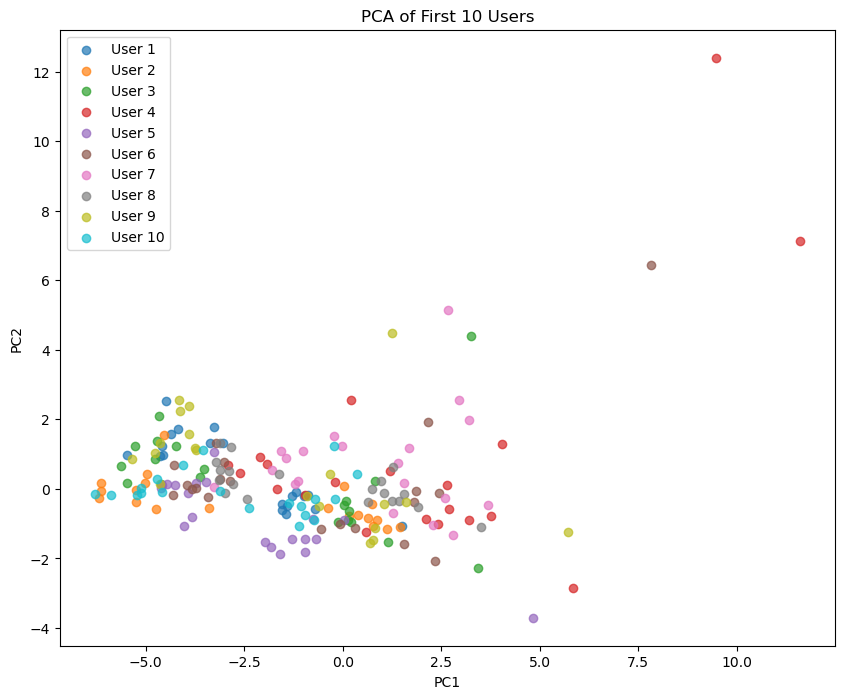

In [14]:
import matplotlib.pyplot as plt

selected_users = sorted(
    p1_data["User_ID"].unique()
)[:10]

plt.figure(figsize=(10,8))

for user in selected_users:
    mask = p1_data["User_ID"] == user

    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        label=f"User {user}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of First 10 Users")
plt.legend()
plt.show()

In [16]:
pd.crosstab(
    p1_data["User_ID"],
    p1_data["Class"]
).head(20)

Class,1,2
User_ID,,
1,10,10
2,10,10
3,10,10
4,10,10
5,10,10
6,10,10
7,10,10
8,10,10
9,10,10


In [17]:
feature_cols = [c for c in p1_data.columns if c.startswith("F")]

class_means = (
    p1_data.groupby("Class")[feature_cols]
    .mean()
)

display(class_means.iloc[:, :10])

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
Class,,,,,,,,,,
1,4.960736e+06,5.248500e+06,4.581336e+06,4.627564e+06,4.170209e+06,2.744818e+06,4.516527e+06,4.216164e+06,4.632318e+06,4.523036e+06
2,2.298691e+06,2.505291e+06,3.212982e+06,1.917600e+06,2.174627e+06,2.537064e+06,2.125118e+06,3.004055e+06,3.290018e+06,1.822864e+06


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = p1_data[feature_cols]
y = p1_data["User_ID"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.7136363636363636


In [19]:
from sklearn.metrics import top_k_accuracy_score

probs = rf.predict_proba(X_test)

top5 = top_k_accuracy_score(
    y_test,
    probs,
    k=5,
    labels=rf.classes_
)

print("Top-5 Accuracy:", top5)

Top-5 Accuracy: 0.9045454545454545


In [21]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 4.8 MB/s eta 0:00:15
   - -------------------------------------- 1.8/69.5 MB 5.6 MB/s eta 0:00:13
   - -------------------------------------- 3.1/69.5 MB 5.8 MB/s eta 0:00:12
   -- ------------------------------------- 4.7/69.5 MB 6.0 MB/s eta 0:00:11
   --- ------------------------------------ 6.0/69.5 MB 6.1 MB/s eta 0:00:11
   ---- ----------------------------------- 7.3/69.5 MB 6.1 MB/s eta 0:00:11
   ----- ---------------------------------- 8.9/69.5 MB 6.2 MB/s eta 0:00:10
   ----- ---------------------------------- 10.2/69.5 MB 6.2 MB/s eta 0:00:10
   ------ --------------------------------- 11.8/69.5 MB 6.3 MB/s eta 0:00:10
   ------- -------------------------------- 13.1/69.5 MB 6.3 MB/s eta 0:00:09
   -------- ------------------------------- 14.4/69.5 MB 6.4 MB/s eta 0:00:09
   ------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

from sklearn.metrics import accuracy_score
print("XGBoost Accuracy:", accuracy_score(y_test, pred))

XGBoost Accuracy: 0.5818181818181818


In [23]:
for user in [1,2,3]:
    subset = p1_data[p1_data["User_ID"] == user]

    print(f"\nUser {user}")
    print(subset["Class"].values)


User 1
[1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2]

User 2
[1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2]

User 3
[1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2]


In [24]:
feature_cols = [c for c in p1_data.columns if c.startswith("F")]

train_df = p1_data[p1_data["Class"] == 1]
test_df  = p1_data[p1_data["Class"] == 2]

X_train = train_df[feature_cols]
y_train = train_df["User_ID"]

X_test = test_df[feature_cols]
y_test = test_df["User_ID"]

print(X_train.shape)
print(X_test.shape)

(1100, 64)
(1100, 64)


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

acc = accuracy_score(y_test, pred)

print("Session Split Accuracy:", acc)

Session Split Accuracy: 0.038181818181818185


In [26]:
from sklearn.metrics import top_k_accuracy_score

probs = rf.predict_proba(X_test)

top5 = top_k_accuracy_score(
    y_test,
    probs,
    k=5,
    labels=rf.classes_
)

print("Session Split Top-5:", top5)

Session Split Top-5: 0.10454545454545454


In [27]:
feature_cols = [c for c in p1_data.columns if c.startswith("F")]

class_means = (
    p1_data.groupby("Class")[feature_cols]
    .mean()
)

diff = abs(class_means.loc[1] - class_means.loc[2])

print("Average feature difference:")
print(diff.mean())

print("\nLargest differences:")
print(diff.sort_values(ascending=False).head(10))

Average feature difference:
1903026.8465909092

Largest differences:
F47    3.072291e+06
F31    3.014964e+06
F15    2.925118e+06
F34    2.889873e+06
F63    2.868782e+06
F42    2.857727e+06
F26    2.852318e+06
F18    2.838200e+06
F33    2.776436e+06
F36    2.758927e+06
dtype: float64


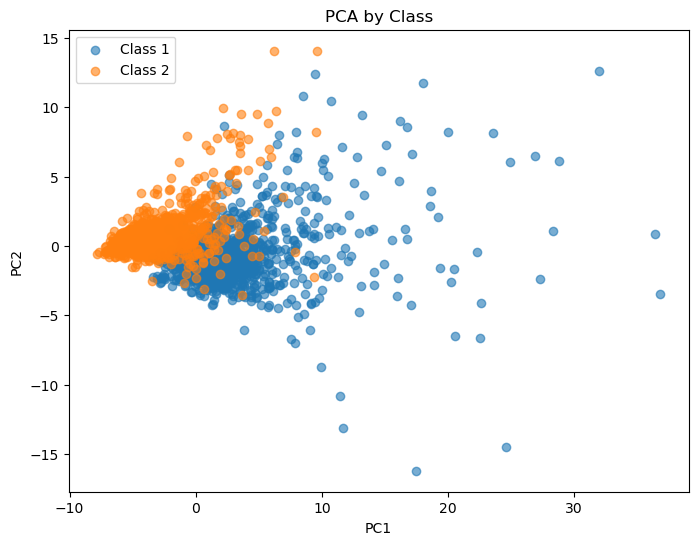

In [28]:
plt.figure(figsize=(8,6))

for c in [1,2]:
    mask = p1_data["Class"] == c

    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        label=f"Class {c}",
        alpha=0.6
    )

plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA by Class")
plt.show()

In [29]:
for user in [1, 2, 3]:
    subset = p1_data[p1_data["User_ID"] == user]

    print(f"\nUser {user}")
    print("Class 1 mean:", subset[subset["Class"] == 1][feature_cols].mean().mean())
    print("Class 2 mean:", subset[subset["Class"] == 2][feature_cols].mean().mean())


User 1
Class 1 mean: 3084875.0
Class 2 mean: 2095843.75

User 2
Class 1 mean: 3536250.0
Class 2 mean: 1828000.0

User 3
Class 1 mean: 3690031.25
Class 2 mean: 1956937.5


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = p1_data[feature_cols]
y = p1_data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Class Accuracy:", accuracy_score(y_test, pred))

Class Accuracy: 0.9840909090909091


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       1.00      0.97      0.98       220
           2       0.97      1.00      0.98       220

    accuracy                           0.98       440
   macro avg       0.98      0.98      0.98       440
weighted avg       0.98      0.98      0.98       440



In [32]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))

[[214   6]
 [  1 219]]


In [33]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = p1_data[feature_cols]
y = p1_data["Class"]          # binary task
groups = p1_data["User_ID"]

gkf = GroupKFold(n_splits=5)

scores = []

for train_idx, test_idx in gkf.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    scores.append(
        accuracy_score(y_test, pred)
    )

print(scores)
print("Mean:", sum(scores)/len(scores))

[0.9795454545454545, 0.9659090909090909, 0.9863636363636363, 0.9886363636363636, 0.9863636363636363]
Mean: 0.9813636363636362


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

results = []

for sheet in xls.sheet_names:

    df = pd.read_excel(file_path, sheet_name=sheet)

    vectors = df["Keystroke Template Vector"].astype(str).apply(
        lambda x: [int(v) for v in x.split()]
    )

    X = pd.DataFrame(vectors.tolist())

    y = df["User_ID"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append([sheet, X.shape[1], acc])

results_df = pd.DataFrame(
    results,
    columns=["Password", "Features", "Accuracy"]
)

results_df.sort_values(
    "Accuracy",
    ascending=False
)

,Password,Features,Accuracy
4,P5,92,0.861364
3,P4,84,0.802273
1,P2,68,0.761364
2,P3,68,0.722727
0,P1,64,0.713636


In [35]:
from sklearn.metrics import top_k_accuracy_score

df = pd.read_excel(file_path, sheet_name="P5")

vectors = df["Keystroke Template Vector"].astype(str).apply(
    lambda x: [int(v) for v in x.split()]
)

X = pd.DataFrame(vectors.tolist())
y = df["User_ID"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

probs = rf.predict_proba(X_test)

top5 = top_k_accuracy_score(
    y_test,
    probs,
    k=5,
    labels=rf.classes_
)

print("Top-5 Accuracy:", top5)

Top-5 Accuracy: 0.9704545454545455


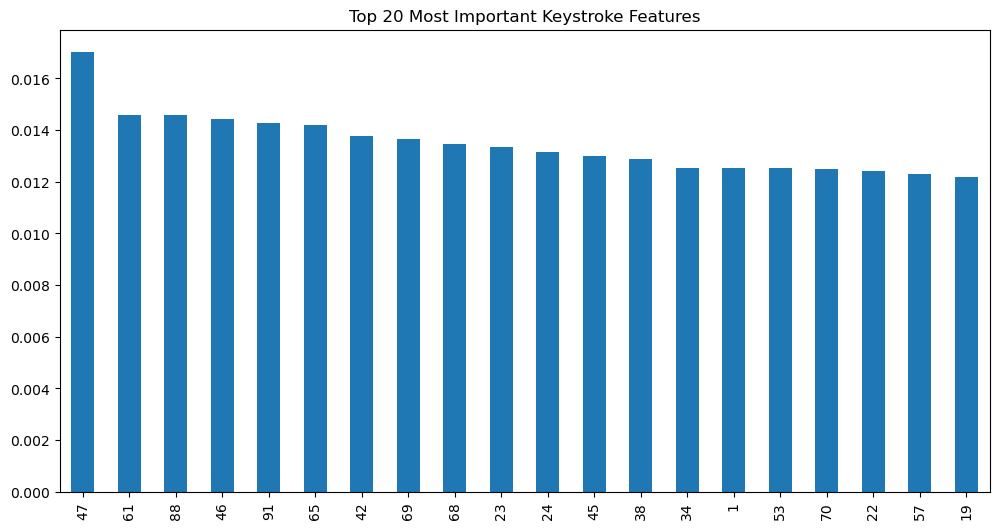

In [37]:
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_
).sort_values(ascending=False)

plt.figure(figsize=(12,6))
importance.head(20).plot(kind="bar")
plt.title("Top 20 Most Important Keystroke Features")
plt.show()

In [38]:
import joblib

joblib.dump(
    rf,
    "typeprint_p5_model.pkl"
)

['typeprint_p5_model.pkl']

In [40]:
import joblib

joblib.dump(
    rf,
    "typeprint_p5_model.pkl"
)

joblib.dump(
    list(X.columns),
    "feature_names.pkl"
)

print("Artifacts saved.")

Artifacts saved.
